In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
# ⚠️ WARNING: Deletes all user files in /kaggle/working/
import shutil, os

for item in os.listdir("/kaggle/working"):
    item_path = os.path.join("/kaggle/working", item)
    try:
        if os.path.isdir(item_path):
            shutil.rmtree(item_path)
        else:
            os.remove(item_path)
    except Exception as e:
        print(f"Could not delete {item_path}: {e}")

print("✅ Cleared /kaggle/working directory.")


✅ Cleared /kaggle/working directory.


In [4]:
# ======================
# 📦 INSTALLS (Kaggle setup)
# ======================
!pip install numpy matplotlib tqdm

# ======================
# 📚 IMPORTS
# ======================
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft2, ifft2, fftfreq
from math import pi
import os
from tqdm import tqdm


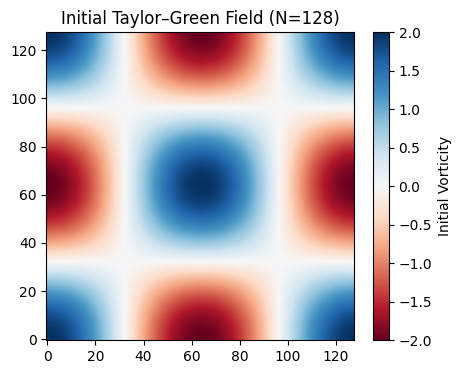

In [5]:
# --- Cell 2: Safe reference parameters (Kaggle-friendly) ---
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft2, ifft2, fftfreq
from tqdm import tqdm

# Moderate resolution & stable config
N_ref = 128
Lx, Ly = 2*np.pi, 2*np.pi
nu = 1e-2           # more viscosity = more damping
dt = 2e-5           # smaller stable timestep
T_final = 0.1       # short physical time (fast)
save_interval = 50
output_filename = "reference_data_safe.npz"

x = np.linspace(0, Lx, N_ref, endpoint=False)
y = np.linspace(0, Ly, N_ref, endpoint=False)
kx = fftfreq(N_ref, d=Lx/N_ref) * 2*np.pi
ky = fftfreq(N_ref, d=Ly/N_ref) * 2*np.pi
KX, KY = np.meshgrid(kx, ky)
K2 = KX**2 + KY**2
K2[0,0] = 1e-20

# Taylor–Green initial condition
X, Y = np.meshgrid(x, y)
u = np.sin(X) * np.cos(Y)
v = -np.cos(X) * np.sin(Y)
omega = np.cos(X)*np.cos(Y)*2

plt.figure(figsize=(5,4))
plt.imshow(omega, cmap='RdBu', origin='lower')
plt.colorbar(label="Initial Vorticity")
plt.title("Initial Taylor–Green Field (N=128)")
plt.show()


In [6]:
def dealias(arr_hat):
    """Apply the 2/3 de-aliasing rule."""
    N = arr_hat.shape[0]
    cutoff = N // 3
    arr_hat[cutoff:-cutoff, :] = 0
    arr_hat[:, cutoff:-cutoff] = 0
    return arr_hat

def compute_rhs(u_hat, v_hat, KX, KY, K2, nu):
    """Compute RHS in Fourier space (nonlinear + viscous terms)."""
    u = np.real(ifft2(u_hat))
    v = np.real(ifft2(v_hat))
    
    ux, uy = np.real(ifft2(1j*KX*u_hat)), np.real(ifft2(1j*KY*u_hat))
    vx, vy = np.real(ifft2(1j*KX*v_hat)), np.real(ifft2(1j*KY*v_hat))

    nonlin_u = -(u*ux + v*uy)
    nonlin_v = -(u*vx + v*vy)

    nonlin_u_hat = fft2(nonlin_u)
    nonlin_v_hat = fft2(nonlin_v)
    
    # Dealias nonlinear terms
    nonlin_u_hat = dealias(nonlin_u_hat)
    nonlin_v_hat = dealias(nonlin_v_hat)
    
    # Pressure projection
    div_hat = 1j*(KX*nonlin_u_hat + KY*nonlin_v_hat)
    p_hat = div_hat / K2
    nonlin_u_hat -= 1j*KX*p_hat
    nonlin_v_hat -= 1j*KY*p_hat

    u_rhs = nonlin_u_hat - nu*K2*u_hat
    v_rhs = nonlin_v_hat - nu*K2*v_hat
    return u_rhs, v_rhs


In [7]:
# --- Cell 4: Run N=256 Reference Simulation ---
u_hat = fft2(u)
v_hat = fft2(v)

t = 0.0
n_steps = int(T_final / dt)

snapshots = []
energy_history = []

for step in tqdm(range(n_steps), desc="Running N=256 reference"):
    u_rhs, v_rhs = compute_rhs(u_hat, v_hat, KX, KY, K2, nu)
    
    # 4th-order Runge-Kutta (RK4)
    u1, v1 = u_hat + 0.5*dt*u_rhs, v_hat + 0.5*dt*v_rhs
    u_rhs2, v_rhs2 = compute_rhs(u1, v1, KX, KY, K2, nu)
    
    u2, v2 = u_hat + 0.5*dt*u_rhs2, v_hat + 0.5*dt*v_rhs2
    u_rhs3, v_rhs3 = compute_rhs(u2, v2, KX, KY, K2, nu)
    
    u3, v3 = u_hat + dt*u_rhs3, v_hat + dt*v_rhs3
    u_rhs4, v_rhs4 = compute_rhs(u3, v3, KX, KY, K2, nu)
    
    u_hat += (dt/6.0)*(u_rhs + 2*u_rhs2 + 2*u_rhs3 + u_rhs4)
    v_hat += (dt/6.0)*(v_rhs + 2*v_rhs2 + 2*v_rhs3 + v_rhs4)
    t += dt

    # Compute kinetic energy
    u_real = np.real(ifft2(u_hat))
    v_real = np.real(ifft2(v_hat))
    KE = 0.5 * np.mean(u_real**2 + v_real**2)
    energy_history.append(KE)

    if step % save_interval == 0:
        snapshots.append((u_real, v_real))

# Convert to arrays and save
snapshots = np.array(snapshots, dtype=object)
np.savez_compressed(output_filename, u=u_real, v=v_real, energy=energy_history, snapshots=snapshots)
print(f"✅ Saved high-resolution reference to {output_filename}")


Running N=256 reference: 100%|██████████| 5000/5000 [01:01<00:00, 81.39it/s]


✅ Saved high-resolution reference to reference_data_safe.npz


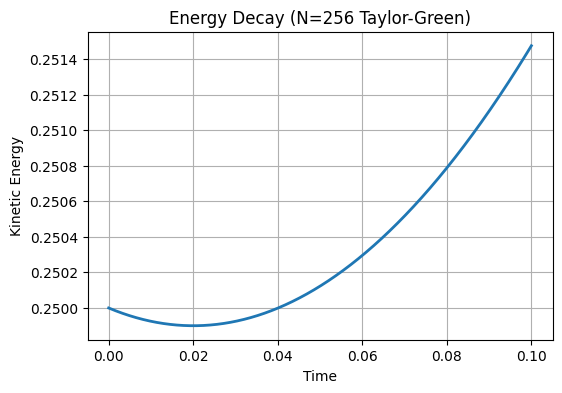

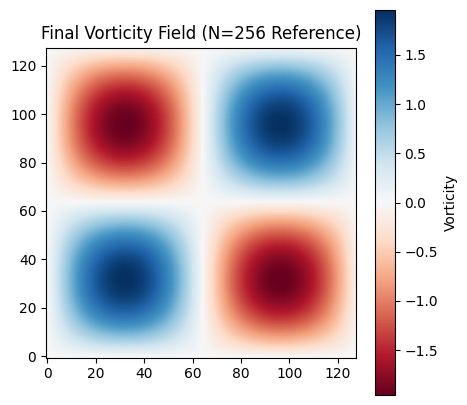

In [8]:
# --- Cell 5: Visualization of Results ---
plt.figure(figsize=(6,4))
plt.plot(np.linspace(0, T_final, len(energy_history)), energy_history, lw=2)
plt.xlabel("Time")
plt.ylabel("Kinetic Energy")
plt.title("Energy Decay (N=256 Taylor-Green)")
plt.grid(True)
plt.show()

plt.figure(figsize=(5,5))
plt.imshow(np.real(ifft2(1j*KX*v_hat - 1j*KY*u_hat)), cmap='RdBu', origin='lower')
plt.title("Final Vorticity Field (N=256 Reference)")
plt.colorbar(label="Vorticity")
plt.show()


## Pseudo Spectral Solver

In [18]:
# --- Cell 1: Setup & Imports ---
!pip install scipy

import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft2, ifft2, fftfreq
from tqdm import tqdm
from scipy.interpolate import interp2d
import os


In [19]:
# --- Cell 2: Utilities & Core Functions ---

def dealias(arr_hat):
    """Apply 2/3 de-aliasing rule."""
    N = arr_hat.shape[0]
    cutoff = N // 3
    arr_hat[cutoff:-cutoff, :] = 0
    arr_hat[:, cutoff:-cutoff] = 0
    return arr_hat

def poisson_solve(omega_hat, KX, KY):
    """Solve ∇²ψ = −ω in Fourier space."""
    k2 = KX**2 + KY**2
    psi_hat = np.zeros_like(omega_hat, dtype=complex)
    mask = k2 != 0
    psi_hat[mask] = -omega_hat[mask] / k2[mask]
    return psi_hat

def velocity_from_stream(psi_hat, KX, KY):
    """Compute velocity from streamfunction ψ̂."""
    u_hat = 1j * KY * psi_hat
    v_hat = -1j * KX * psi_hat
    u = np.real(ifft2(u_hat))
    v = np.real(ifft2(v_hat))
    return u, v

def nonlinear_term(omega_hat, KX, KY):
    """Return nonlinear advection term in Fourier space (corrected sign convention)."""
    psi_hat = poisson_solve(omega_hat, KX, KY)
    u, v = velocity_from_stream(psi_hat, KX, KY)
    omega = -np.real(ifft2(omega_hat))       # <-- flipped sign
    dωdx = -np.real(ifft2(1j*KX*omega_hat))  # <-- flipped sign for consistency
    dωdy = -np.real(ifft2(1j*KY*omega_hat))
    adv = u*dωdx + v*dωdy
    adv_hat = fft2(adv)
    return dealias(adv_hat)  # no extra minus here

def run_taylor_green(N=32, Re=100.0, dt=0.05, T=5.0, snap_dt=0.1, save_path="taylor_green_N32.npz"):
    """Run 2-D Taylor–Green pseudo-spectral solver and save results."""
    L = 2*np.pi
    nu = 1/Re
    x = np.linspace(0, L, N, endpoint=False)
    y = np.linspace(0, L, N, endpoint=False)
    kx = fftfreq(N, d=L/N)*2*np.pi
    ky = fftfreq(N, d=L/N)*2*np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    K2 = KX**2 + KY**2
    K2[0,0] = 1e-20

    # initial condition
    X, Y = np.meshgrid(x, y, indexing='ij')
    u0 =  np.sin(X)*np.cos(Y)
    v0 = -np.cos(X)*np.sin(Y)
    ω0 = 2*np.cos(X)*np.cos(Y)
    ω_hat = fft2(ω0)

    t = 0.0
    Nt = int(np.ceil(T/dt))
    next_snap = 0.0
    times, energies, enstrophies, snapshots = [], [], [], []

    for step in tqdm(range(Nt), desc=f"Running N={N}"):
        k1 = nonlinear_term(ω_hat, KX, KY) + nu*(-K2*ω_hat)
        k2 = nonlinear_term(ω_hat + 0.5*dt*k1, KX, KY) + nu*(-K2*(ω_hat + 0.5*dt*k1))
        k3 = nonlinear_term(ω_hat + 0.5*dt*k2, KX, KY) + nu*(-K2*(ω_hat + 0.5*dt*k2))
        k4 = nonlinear_term(ω_hat + dt*k3, KX, KY) + nu*(-K2*(ω_hat + dt*k3))
        ω_hat += dt*(k1 + 2*k2 + 2*k3 + k4)/6.0
        ω_hat = dealias(ω_hat)
        t += dt

        if t >= next_snap - 1e-12:
            ψ_hat = poisson_solve(ω_hat, KX, KY)
            u, v = velocity_from_stream(ψ_hat, KX, KY)
            ω = -np.real(ifft2(ω_hat))
            E = 0.5*np.mean(u**2 + v**2)
            Z = 0.5*np.mean(ω**2)
            times.append(t)
            energies.append(E)
            enstrophies.append(Z)
            snapshots.append(ω.copy())
            next_snap += snap_dt

    results = {
        "N": N, "Re": Re, "dt": dt, "T": T,
        "x": x, "y": y,
        "times": np.array(times),
        "energies": np.array(energies),
        "enstrophies": np.array(enstrophies),
        "snapshots": np.array(snapshots)
    }
    np.savez_compressed(save_path, **results)
    print(f"✅ Saved results to {save_path}")
    return results


In [20]:
# --- Cell 3: Run N=32 Simulation ---
res32 = run_taylor_green(N=32, Re=100.0, dt=0.05, T=5.0, snap_dt=0.1, save_path="solver_N32.npz")

Running N=32: 100%|██████████| 100/100 [00:00<00:00, 668.47it/s]

✅ Saved results to solver_N32.npz


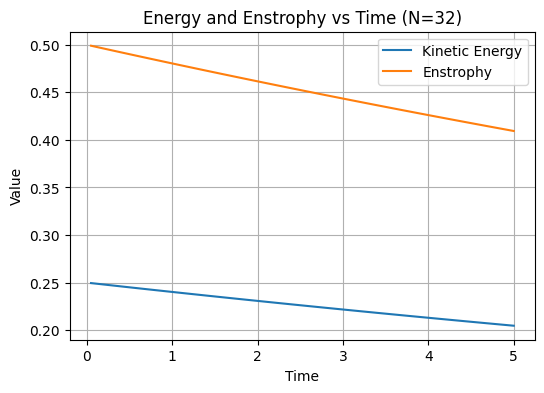

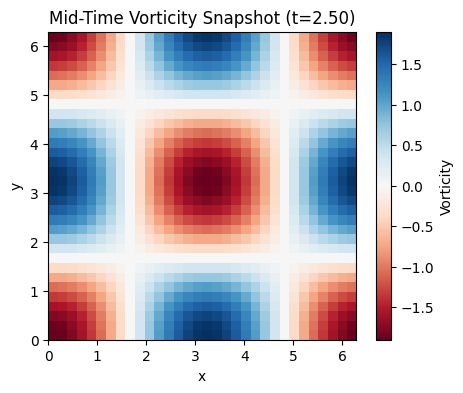

In [21]:
# --- Cell 4: Plot Energy, Enstrophy, and Vorticity Snapshot ---
plt.figure(figsize=(6,4))
plt.plot(res32['times'], res32['energies'], label="Kinetic Energy")
plt.plot(res32['times'], res32['enstrophies'], label="Enstrophy")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Energy and Enstrophy vs Time (N=32)")
plt.legend(); plt.grid(True)
plt.show()

mid = len(res32['snapshots'])//2
plt.figure(figsize=(5,4))
plt.imshow(res32['snapshots'][mid].T, origin='lower', extent=(0,2*np.pi,0,2*np.pi), cmap='RdBu')
plt.colorbar(label="Vorticity")
plt.title(f"Mid-Time Vorticity Snapshot (t={res32['times'][mid]:.2f})")
plt.xlabel("x"); plt.ylabel("y")
plt.show()


📊 L2 Error:      2.1596e-01
📊 L∞ Error:      4.0209e-01
📊 Correlation:   0.9803


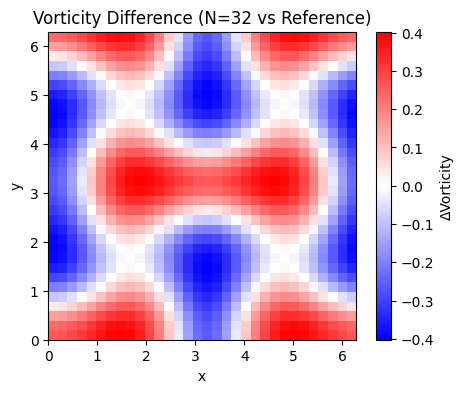

In [22]:
# --- Cell 5: Compute Error Metrics vs Reference (fixed version) ---

# Load reference data
ref = np.load("reference_data_safe.npz", allow_pickle=True)
u_ref = ref['u']
v_ref = ref['v']

# --- Compute vorticity for reference field ---
Nx_ref, Ny_ref = u_ref.shape
kx_ref = np.fft.fftfreq(Nx_ref, d=(2*np.pi)/Nx_ref) * 2*np.pi
ky_ref = np.fft.fftfreq(Ny_ref, d=(2*np.pi)/Ny_ref) * 2*np.pi
KX_ref, KY_ref = np.meshgrid(kx_ref, ky_ref, indexing='ij')

u_hat = fft2(u_ref)
v_hat = fft2(v_ref)
ω_hat_ref = 1j * KX_ref * v_hat - 1j * KY_ref * u_hat
ω_ref = np.real(ifft2(ω_hat_ref))

# --- Interpolate reference vorticity to 32×32 grid ---
x_ref = np.linspace(0, 2*np.pi, Nx_ref, endpoint=False)
y_ref = np.linspace(0, 2*np.pi, Ny_ref, endpoint=False)
x32, y32 = res32['x'], res32['y']
X_ref, Y_ref = np.meshgrid(x_ref, y_ref, indexing='ij')
X32, Y32 = np.meshgrid(x32, y32, indexing='ij')

# Use scipy interpolation
from scipy.interpolate import RegularGridInterpolator
interp_func = RegularGridInterpolator((x_ref, y_ref), ω_ref)
ω_ref_interp = interp_func(np.array([X32.flatten(), Y32.flatten()]).T).reshape(X32.shape)

# --- Predicted vorticity (final snapshot) ---
ω_pred = res32['snapshots'][-1]

# --- Error metrics ---
L2_err = np.linalg.norm(ω_pred - ω_ref_interp) / np.linalg.norm(ω_ref_interp)
Linf_err = np.max(np.abs(ω_pred - ω_ref_interp))
corr = np.corrcoef(ω_pred.flatten(), ω_ref_interp.flatten())[0,1]

print(f"📊 L2 Error:      {L2_err:.4e}")
print(f"📊 L∞ Error:      {Linf_err:.4e}")
print(f"📊 Correlation:   {corr:.4f}")

# --- Visualization ---
plt.figure(figsize=(5,4))
plt.imshow(ω_pred - ω_ref_interp, origin='lower', cmap='bwr', extent=(0,2*np.pi,0,2*np.pi))
plt.colorbar(label="ΔVorticity")
plt.title("Vorticity Difference (N=32 vs Reference)")
plt.xlabel("x"); plt.ylabel("y")
plt.show()


In [23]:
# --- Cell 6: Save Summary Metrics ---
metrics = {
    "L2_error": L2_err,
    "Linf_error": Linf_err,
    "correlation": corr,
    "final_energy": res32['energies'][-1],
    "final_enstrophy": res32['enstrophies'][-1]
}
np.savez_compressed("metrics_N32.npz", **metrics)
print("✅ Saved metrics to metrics_N32.npz")

✅ Saved metrics to metrics_N32.npz


## Robust metrics (auto sign-check) vs reference

📊 L2 Error:    2.1596e-01
📊 L∞ Error:    4.0209e-01
📊 Correlation: 0.9803  (sign-flip used: False)


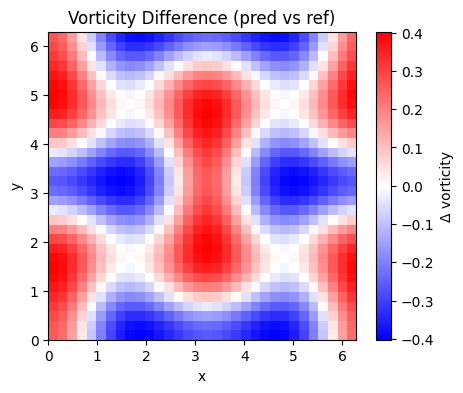

In [24]:
# --- Robust metrics with auto sign-check ---

import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft2, ifft2, fftfreq
from scipy.interpolate import RegularGridInterpolator

def vorticity_from_uv(u, v):
    Nx, Ny = u.shape
    kx = fftfreq(Nx, d=(2*np.pi)/Nx) * 2*np.pi
    ky = fftfreq(Ny, d=(2*np.pi)/Ny) * 2*np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    u_hat, v_hat = fft2(u), fft2(v)
    w_hat = 1j*KX*v_hat - 1j*KY*u_hat
    return np.real(ifft2(w_hat))

def interp_field_to_grid(field_ref, x_ref, y_ref, x_tgt, y_tgt):
    from scipy.interpolate import RegularGridInterpolator
    X_t, Y_t = np.meshgrid(x_tgt, y_tgt, indexing='ij')
    interp = RegularGridInterpolator((x_ref, y_ref), field_ref)
    return interp(np.c_[X_t.ravel(), Y_t.ravel()]).reshape(X_t.shape)

def compute_metrics_vorticity(w_pred, x_pred, y_pred, ref_npz_path="reference_data_safe.npz", plot_diff=True):
    ref = np.load(ref_npz_path, allow_pickle=True)
    u_ref, v_ref = ref['u'], ref['v']
    Nx_ref, Ny_ref = u_ref.shape
    x_ref = np.linspace(0, 2*np.pi, Nx_ref, endpoint=False)
    y_ref = np.linspace(0, 2*np.pi, Ny_ref, endpoint=False)
    w_ref = vorticity_from_uv(u_ref, v_ref)

    # Interpolate reference to pred grid
    w_ref_interp = interp_field_to_grid(w_ref, x_ref, y_ref, x_pred, y_pred)

    # Auto sign-check: pick sign that maximizes correlation
    def metrics(w):
        L2 = np.linalg.norm(w - w_ref_interp) / np.linalg.norm(w_ref_interp)
        Linf = np.max(np.abs(w - w_ref_interp))
        corr = np.corrcoef(w.ravel(), w_ref_interp.ravel())[0,1]
        return L2, Linf, corr

    L2_a, Linf_a, corr_a = metrics(w_pred)
    L2_b, Linf_b, corr_b = metrics(-w_pred)

    if abs(corr_b) > abs(corr_a):
        flip_used = True
        w_use, L2, Linf, corr = -w_pred, L2_b, Linf_b, corr_b
    else:
        flip_used = False
        w_use, L2, Linf, corr = w_pred, L2_a, Linf_a, corr_a

    print(f"📊 L2 Error:    {L2:.4e}")
    print(f"📊 L∞ Error:    {Linf:.4e}")
    print(f"📊 Correlation: {corr:.4f}  (sign-flip used: {flip_used})")

    if plot_diff:
        plt.figure(figsize=(5,4))
        plt.imshow((w_use - w_ref_interp).T, origin='lower', cmap='bwr',
                   extent=(0,2*np.pi,0,2*np.pi))
        plt.colorbar(label="Δ vorticity")
        plt.title("Vorticity Difference (pred vs ref)")
        plt.xlabel("x"); plt.ylabel("y")
        plt.show()

    return dict(L2=L2, Linf=Linf, corr=corr, flipped=flip_used)

# usage (re-using your res32 from the solver cell):
w_pred = res32['snapshots'][-1]
metrics32 = compute_metrics_vorticity(w_pred, res32['x'], res32['y'])


## Energy spectrum comparison (N=32 vs reference)

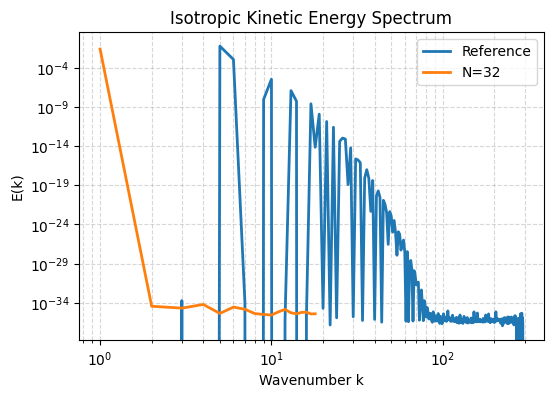

In [25]:
# --- Isotropic kinetic energy spectra (1D) comparison ---

def energy_spectrum_uv(u, v):
    Nx, Ny = u.shape
    u_hat, v_hat = fft2(u), fft2(v)
    E2D = 0.5*(np.abs(u_hat)**2 + np.abs(v_hat)**2)/(Nx*Ny)**2

    kx = fftfreq(Nx, d=(2*np.pi)/Nx) * Nx/(2*np.pi)  # integer-like wavenumbers
    ky = fftfreq(Ny, d=(2*np.pi)/Ny) * Ny/(2*np.pi)
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    K = np.sqrt(KX**2 + KY**2)

    kmax = int(np.floor(K.max()))
    E1D = np.zeros(kmax+1)
    counts = np.zeros(kmax+1)

    for i in range(Nx):
        for j in range(Ny):
            kbin = int(np.round(K[i,j]))
            if kbin <= kmax:
                E1D[kbin] += E2D[i,j]
                counts[kbin] += 1
    counts[counts==0] = 1.0
    return np.arange(kmax+1), E1D / counts

# reconstruct u,v from your N=32 ω snapshot (via streamfunction)
def uv_from_vorticity(w, x, y):
    Nx, Ny = w.shape
    kx = fftfreq(Nx, d=(2*np.pi)/Nx) * 2*np.pi
    ky = fftfreq(Ny, d=(2*np.pi)/Ny) * 2*np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    w_hat = fft2(w)
    k2 = KX**2 + KY**2
    psi_hat = np.zeros_like(w_hat, dtype=complex)
    mask = k2 != 0
    psi_hat[mask] = -w_hat[mask] / k2[mask]
    u = np.real(ifft2(1j*KY*psi_hat))
    v = np.real(ifft2(-1j*KX*psi_hat))
    return u, v

# pred (N=32)
u32, v32 = uv_from_vorticity(res32['snapshots'][-1], res32['x'], res32['y'])
k32, E32 = energy_spectrum_uv(u32, v32)

# reference (already has u_ref, v_ref from previous cell)
ref = np.load("reference_data_safe.npz", allow_pickle=True)
u_ref, v_ref = ref['u'], ref['v']
kref, Eref = energy_spectrum_uv(u_ref, v_ref)

plt.figure(figsize=(6,4))
plt.loglog(kref[1:], Eref[1:], label="Reference", linewidth=2)
plt.loglog(k32[1:],  E32[1:],  label="N=32", linewidth=2)
plt.xlabel("Wavenumber k")
plt.ylabel("E(k)")
plt.title("Isotropic Kinetic Energy Spectrum")
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend()
plt.show()


## Extra diagnostics + save tidy metrics

In [26]:
# --- Divergence check + save tidy metrics ---

def divergence_norm(u, v):
    Nx, Ny = u.shape
    kx = fftfreq(Nx, d=(2*np.pi)/Nx) * 2*np.pi
    ky = fftfreq(Ny, d=(2*np.pi)/Ny) * 2*np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    u_hat, v_hat = fft2(u), fft2(v)
    div = np.real(ifft2(1j*KX*u_hat + 1j*KY*v_hat))
    return np.linalg.norm(div) / np.sqrt(Nx*Ny)

u32, v32 = uv_from_vorticity(res32['snapshots'][-1], res32['x'], res32['y'])
div_err = divergence_norm(u32, v32)
print(f"∥∇·u∥₂ (N=32): {div_err:.3e}")

# save a tidy record
summary = {
    "N": int(res32['N']) if 'N' in res32 else 32,
    "L2": float(metrics32['L2']),
    "Linf": float(metrics32['Linf']),
    "corr": float(metrics32['corr']),
    "divL2": float(div_err),
    "final_energy": float(res32['energies'][-1]),
    "final_enstrophy": float(res32['enstrophies'][-1]),
}
np.savez_compressed("metrics_N32_tidy.npz", **summary)
print("✅ Saved metrics to metrics_N32_tidy.npz")


∥∇·u∥₂ (N=32): 1.117e-15
✅ Saved metrics to metrics_N32_tidy.npz


# PINN

In [28]:
!pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 86.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 69.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 4.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 12.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 75.7 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.

In [30]:

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [31]:
# --- PINN architecture ---
class PINN_NS(torch.nn.Module):
    def __init__(self, in_dim=3, out_dim=2, hidden_dim=128, n_layers=8):
        super(PINN_NS, self).__init__()
        layers = [torch.nn.Linear(in_dim, hidden_dim), torch.nn.Tanh()]
        for _ in range(n_layers - 1):
            layers += [torch.nn.Linear(hidden_dim, hidden_dim), torch.nn.Tanh()]
        layers += [torch.nn.Linear(hidden_dim, out_dim)]
        self.model = torch.nn.Sequential(*layers)

    def forward(self, x, y, t):
        return self.model(torch.cat([x, y, t], dim=1))


In [32]:
# --- Navier–Stokes residuals ---
def navier_stokes_residual(model, x, y, t, nu):
    x.requires_grad_(True)
    y.requires_grad_(True)
    t.requires_grad_(True)

    out = model(x, y, t)
    u, v = out[:, [0]], out[:, [1]]

    # Derivatives
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    v_t = torch.autograd.grad(v, t, torch.ones_like(v), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_y = torch.autograd.grad(u, y, torch.ones_like(u), create_graph=True)[0]
    v_x = torch.autograd.grad(v, x, torch.ones_like(v), create_graph=True)[0]
    v_y = torch.autograd.grad(v, y, torch.ones_like(v), create_graph=True)[0]

    # Second derivatives
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y, torch.ones_like(u), create_graph=True)[0]
    v_xx = torch.autograd.grad(v_x, x, torch.ones_like(v), create_graph=True)[0]
    v_yy = torch.autograd.grad(v_y, y, torch.ones_like(v), create_graph=True)[0]

    # PDE residuals (without explicit pressure term)
    f_u = u_t + (u*u_x + v*u_y) - nu*(u_xx + u_yy)
    f_v = v_t + (u*v_x + v*v_y) - nu*(v_xx + v_yy)
    continuity = u_x + v_y
    return f_u, f_v, continuity


In [33]:
# --- Training data: collocation + initial conditions ---
def generate_training_data(N_col=10000, N_ic=1000, T_final=1.0):
    x_col = 2*np.pi*np.random.rand(N_col, 1)
    y_col = 2*np.pi*np.random.rand(N_col, 1)
    t_col = T_final*np.random.rand(N_col, 1)

    x_ic = 2*np.pi*np.random.rand(N_ic, 1)
    y_ic = 2*np.pi*np.random.rand(N_ic, 1)
    t_ic = np.zeros_like(x_ic)

    u_ic = np.sin(x_ic)*np.cos(y_ic)
    v_ic = -np.cos(x_ic)*np.sin(y_ic)

    return {
        "col": (x_col, y_col, t_col),
        "ic": (x_ic, y_ic, t_ic, u_ic, v_ic)
    }


In [34]:
# --- Combined PINN loss ---
def pinn_loss(model, data, nu):
    x_col, y_col, t_col = [torch.tensor(a, dtype=torch.float32, device=device) for a in data["col"]]
    x_ic, y_ic, t_ic, u_ic, v_ic = [torch.tensor(a, dtype=torch.float32, device=device) for a in data["ic"]]

    f_u, f_v, f_c = navier_stokes_residual(model, x_col, y_col, t_col, nu)
    loss_pde = (f_u.pow(2).mean() + f_v.pow(2).mean() + f_c.pow(2).mean())

    uv_ic_pred = model(x_ic, y_ic, t_ic)
    u_ic_pred, v_ic_pred = uv_ic_pred[:, [0]], uv_ic_pred[:, [1]]
    loss_ic = ((u_ic_pred - u_ic)**2).mean() + ((v_ic_pred - v_ic)**2).mean()

    return loss_pde + loss_ic


In [35]:
# --- PINN training ---
def train_pinn(model, data, nu=0.01, lr=1e-3, epochs=3000, save_path="pinn_ns.pt"):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []

    for epoch in tqdm(range(epochs)):
        opt.zero_grad()
        loss = pinn_loss(model, data, nu)
        loss.backward()
        opt.step()

        losses.append(loss.item())
        if epoch % 500 == 0:
            print(f"Epoch {epoch}: Loss = {loss.item():.3e}")

    torch.save(model.state_dict(), save_path)
    print(f"✅ Model saved to {save_path}")
    return losses


In [36]:
# --- Evaluation utilities ---
def evaluate_pinn(model, nx=32, ny=32, t_eval=1.0):
    x = np.linspace(0, 2*np.pi, nx)
    y = np.linspace(0, 2*np.pi, ny)
    X, Y = np.meshgrid(x, y, indexing='ij')
    t = t_eval*np.ones_like(X)

    X_t = torch.tensor(X.flatten()[:, None], dtype=torch.float32, device=device)
    Y_t = torch.tensor(Y.flatten()[:, None], dtype=torch.float32, device=device)
    T_t = torch.tensor(t.flatten()[:, None], dtype=torch.float32, device=device)

    with torch.no_grad():
        uv_pred = model(X_t, Y_t, T_t).cpu().numpy()

    u = uv_pred[:, 0].reshape(nx, ny)
    v = uv_pred[:, 1].reshape(nx, ny)
    return X, Y, u, v

def plot_field(X, Y, U, V, title="PINN Velocity Field"):
    plt.figure(figsize=(5,5))
    plt.streamplot(X, Y, U, V, density=1.2, color=np.sqrt(U**2 + V**2), cmap='plasma')
    plt.title(title)
    plt.xlabel("x"); plt.ylabel("y")
    plt.show()


  0%|          | 1/3000 [00:05<4:45:04,  5.70s/it]

Epoch 0: Loss = 5.049e-01


 17%|█▋        | 501/3000 [13:59<1:11:47,  1.72s/it]

Epoch 500: Loss = 1.094e-01


 33%|███▎      | 1001/3000 [27:55<57:58,  1.74s/it] 

...

Epoch 2000: Loss = 4.334e-02


 83%|████████▎ | 2501/3000 [1:09:39<13:30,  1.62s/it]

Epoch 2500: Loss = 4.703e-02


100%|██████████| 3000/3000 [1:23:28<00:00,  1.67s/it]


✅ Model saved to pinn_ns.pt


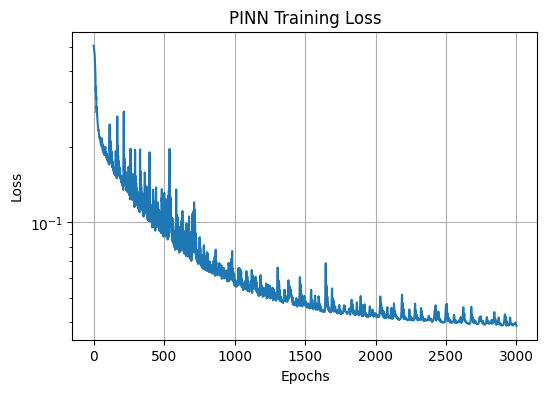

In [37]:
# --- Train PINN ---
data = generate_training_data(N_col=10000, N_ic=1000, T_final=1.0)
model = PINN_NS()
losses = train_pinn(model, data, nu=0.01, lr=1e-3, epochs=3000, save_path="pinn_ns.pt")

plt.figure(figsize=(6,4))
plt.semilogy(losses)
plt.title("PINN Training Loss")
plt.xlabel("Epochs"); plt.ylabel("Loss")
plt.grid(True)
plt.show()


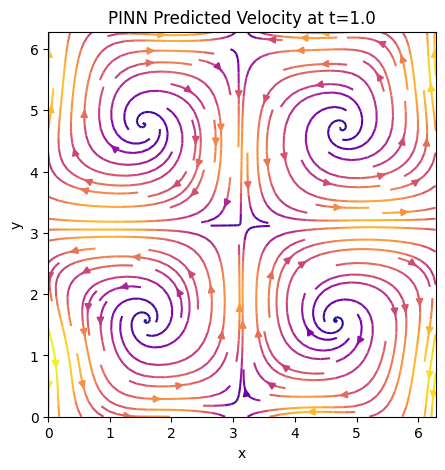

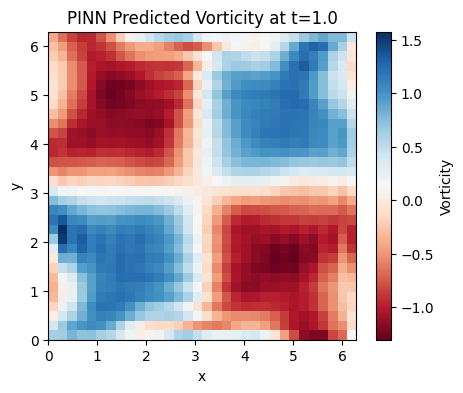

📊 L2 Error:    1.2671e+00
📊 L∞ Error:    2.7711e+00
📊 Correlation: -0.0045  (sign-flip used: False)


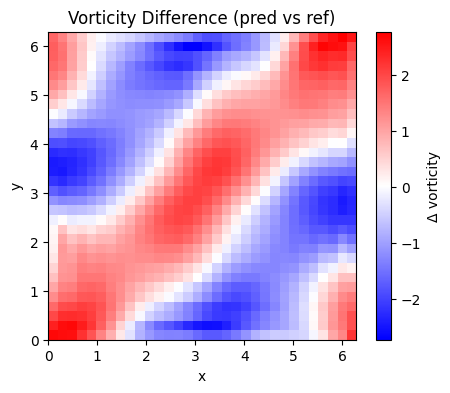

In [42]:
def plot_field(X, Y, U, V, title="PINN Velocity Field"):
    # Convert to 1D monotonic coordinate vectors
    x = np.unique(X)
    y = np.unique(Y)
    U_plot, V_plot = U.T, V.T  # transpose for correct orientation

    plt.figure(figsize=(5, 5))
    plt.streamplot(x, y, U_plot, V_plot, density=1.2,
                   color=np.sqrt(U_plot**2 + V_plot**2), cmap='plasma')
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()



# --- Evaluate PINN and compare ---
X, Y, U, V = evaluate_pinn(model, nx=32, ny=32, t_eval=1.0)
plot_field(X, Y, U, V, title="PINN Predicted Velocity at t=1.0")

# Compute vorticity and compare to reference
Nx, Ny = U.shape
kx = np.fft.fftfreq(Nx, d=(2*np.pi)/Nx)*2*np.pi
ky = np.fft.fftfreq(Ny, d=(2*np.pi)/Ny)*2*np.pi
KX, KY = np.meshgrid(kx, ky, indexing='ij')
u_hat, v_hat = np.fft.fft2(U), np.fft.fft2(V)
omega_hat = 1j*KX*v_hat - 1j*KY*u_hat
omega = np.real(np.fft.ifft2(omega_hat))

plt.figure(figsize=(5,4))
plt.imshow(omega.T, origin='lower', cmap='RdBu', extent=(0,2*np.pi,0,2*np.pi))
plt.colorbar(label="Vorticity")
plt.title("PINN Predicted Vorticity at t=1.0")
plt.xlabel("x"); plt.ylabel("y")
plt.show()

# --- Safe call: wrap PINN grid into [0, 2π) for periodic BCs ---
x_eval = (np.unique(X) % (2*np.pi))
y_eval = (np.unique(Y) % (2*np.pi))

metrics_pinn = compute_metrics_vorticity(omega, x_eval, y_eval)


### References
1. Taylor, G. I., & Green, A. E. (1937). *Mechanism of the production of small eddies from large ones.* Proc. R. Soc. Lond. A, 158(895), 499–521.
2. Canuto, C., Hussaini, M. Y., Quarteroni, A., & Zang, T. A. (2006). *Spectral Methods: Fundamentals in Single Domains.* Springer.
3. Peyret, R. (2002). *Spectral Methods for Incompressible Viscous Flow.* Springer.
4. Tuckerman, L. S., & Barkley, D. (2000). *Bifurcation analysis for time-steppers.* In *Numerical Methods for Bifurcation Problems and Large-Scale Dynamical Systems*, Springer.
